# 02 — Exploração dos experimentos

Log de treinos Random Forest sobre SINASC-BA (`experiments/experiments.jsonl`).

**Objetivos:**
- Acompanhar evolução de AUC / F1 ao longo das versões de features
- Comparar ablations (município, target encoding, TPNASCASSI, v8)
- Inspecionar importâncias e relação cardinalidade × desempenho
- Separar runs com CV vs hold-out puro

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
LOG_PATH = ROOT / "experiments" / "experiments.jsonl"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 100

METRIC_LABELS = {
    "roc_auc": "AUC-ROC",
    "f1": "F1",
    "accuracy": "Acurácia",
}

LOG_PATH

PosixPath('/Users/antonielmagalhaes/d/acad/ia-final/ia-iii/experiments/experiments.jsonl')

## 1 — Carregar o log

In [3]:
def load_experiments(path: Path) -> pd.DataFrame:
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    df = pd.json_normalize(rows, sep=".")
    df["exp_num"] = df["id"].str.extract(r"(\d+)")[0].astype(int)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    for col in ["metrics.roc_auc", "metrics.f1", "metrics.accuracy"]:
        df[col] = df[col].astype(float)
    df["tag"] = df["tag"].fillna("").replace("", "(sem tag)")
    df["notes"] = df["notes"].fillna("")
    df["validation"] = df.get("validation", "holdout").fillna("holdout")
    return df.sort_values("exp_num").reset_index(drop=True)


def holdout_auc(row: pd.Series) -> float:
    if pd.notna(row.get("holdout_metrics.roc_auc")):
        return float(row["holdout_metrics.roc_auc"])
    return float(row["metrics.roc_auc"])


def expand_top_importances(path: Path, tags: pd.Series) -> pd.DataFrame:
    records: list[dict] = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        row = json.loads(line)
        for rank, (feature, score) in enumerate(row.get("top_importances", {}).items(), start=1):
            records.append(
                {
                    "id": row["id"],
                    "tag": tags.get(row["id"], row.get("tag") or "(sem tag)"),
                    "rank": rank,
                    "feature": feature,
                    "importance": score,
                }
            )
    return pd.DataFrame(records)


exps = load_experiments(LOG_PATH)
exps["holdout_auc"] = exps.apply(holdout_auc, axis=1)
tag_by_id = exps.set_index("id")["tag"]
imps = expand_top_importances(LOG_PATH, tag_by_id)

print(f"{len(exps)} experimentos · melhor hold-out AUC = {exps['holdout_auc'].max():.3f}")
exps[["id", "tag", "validation", "holdout_auc", "metrics.f1", "n_features", "is_best"]].tail(8)

19 experimentos · melhor hold-out AUC = 0.920


,id,tag,validation,holdout_auc,metrics.f1,n_features,is_best
11,exp_012,v7-tuned,holdout,0.9198,0.8376,64,False
12,exp_013,v7,holdout,0.9198,0.8376,64,False
13,exp_014,v7,holdout,0.9198,0.8376,64,False
14,exp_015,v7,holdout,0.9200,0.8383,54,True
15,exp_016,v7,holdout,0.9196,0.8373,41,False
16,exp_017,v7,holdout,0.9196,0.8373,41,False
17,exp_018,v7-sem-tpnassassi,holdout,0.8729,0.7851,35,False
18,exp_019,v8,holdout,0.8792,0.7911,53,False


## 2 — Visão geral (tabela)

In [4]:
overview = exps.assign(
    auc=lambda d: d["holdout_auc"].map(lambda x: f"{x:.3f}"),
    f1=lambda d: d["metrics.f1"].map(lambda x: f"{x:.3f}"),
    acc=lambda d: d["metrics.accuracy"].map(lambda x: f"{x:.3f}"),
    best=lambda d: np.where(d["is_best"], "★", ""),
)[
    ["id", "best", "tag", "validation", "auc", "f1", "acc", "n_features", "notes"]
].rename(
    columns={
        "validation": "validação",
        "n_features": "# feat",
        "notes": "notas",
    }
)

overview.style.hide(axis="index").set_properties(
    subset=["notas"],
    **{"max-width": "420px", "text-align": "left"},
)

id,best,tag,validação,auc,f1,acc,# feat,notas
exp_001,,(sem tag),holdout,0.694,0.624,0.642,421,"baseline v0: idade, cesáreas anteriores, pré-natal, município"
exp_002,,(sem tag),holdout,0.694,0.624,0.642,421,
exp_003,,(sem tag),cv+holdout,0.694,0.623,0.641,421,
exp_004,,v2,holdout,0.741,0.673,0.682,447,"Expansão v0→v2. v1 (+obstétrico): paridade (0/1) e tipo_gravidez (one-hot). v2 (+perfil social da mãe): escolaridade_mae_agregada (ESCMAEAGR1) e raca_cor_mae (one-hot). RF 100 árvores, hold-out 80/20, sem CV. AUC 0,694→0,741 (+0,047 vs v0); F1 0,624→0,673. Novos determinantes no top: paridade e escolaridade."
exp_005,,v4,holdout,0.748,0.678,0.686,453,"Expansão v2→v4. v3 (+gestação): semanas_gestacao/SEMAGESTAC (numérica; sem GESTACAO agrupado). v4 (+pré-natal refinado): remove numero_consultas_prenatal e usa indice_kotelchuck_prenatal (adequação vs contagem). Hold-out 80/20, RF 100 árvores. AUC 0,741→0,748 (+0,007 vs v2); F1 0,673→0,678. semanas_gestacao entra no top 3 (10,6%); KOTELCHUCK diluído no one-hot."
exp_006,,v5,holdout,0.849,0.762,0.761,464,"v5 (+assistência ao parto): tipo_apresentacao_fetal (TPAPRESENT) e tipo_profissional_assistencia_parto (TPNASCASSI), ambos one-hot. Hold-out 80/20, RF 100 árvores. AUC 0,748→0,849 (+0,101 vs v4); F1 0,678→0,762. TPNASCASSI domina importância (médico vs enfermeiro/obstetra); apresentação fetal ainda diluída no one-hot."
exp_007,,v6,holdout,0.878,0.793,0.792,1435,"v6 (+território/local): local_nascimento (LOCNASC, 5 cats — hospital/domicílio/etc.) e codigo_estabelecimento_saude (CODESTAB, 1022 estabelecimentos one-hot). 1435 features totais. Hold-out 80/20, RF 100 árvores. AUC 0,849→0,878 (+0,029 vs v5); F1 0,762→0,793. LOCNASC importância agregada ~0,5%; CODESTAB diluído (~0,6% no maior CNES). Ganho veio mais da cardinalidade do estabelecimento que do local em si."
exp_008,,v6-sem-municipio,holdout,0.872,0.790,0.788,1017,"Ablation v6: remove codigo_municipio_residencia (418 dummies one-hot). Mesmas demais features v6 (LOCNASC + CODESTAB). 1435→1017 features (−418). Hold-out 80/20, RF 100 árvores. AUC 0,878→0,872 (−0,006 vs v6); F1 0,793→0,790. Perda pequena; município capturava efeito territorial marginal com CODESTAB já presente. Treino ~35s vs ~54s."
exp_009,,v6-target-encode,holdout,0.883,0.800,0.797,53,"v6 com target encoding (smoothing=10): codigo_municipio_residencia e codigo_estabelecimento_saude → taxa cesárea suavizada do treino (1 col cada). Demais categóricas permanecem one-hot. 1435→53 features. Hold-out 80/20. AUC 0,878→0,883 (+0,006 vs v6 one-hot); F1 0,793→0,800. CNES taxa (23%) e município taxa (13%) sobem ao top — efeito territorial interpretável. Treino ~8s vs ~54s."
exp_010,,v6-target-encode,cv+holdout,0.883,0.797,0.793,53,v6 com target encoding (taxa cesárea suavizada) para município e CNES


## 3 — Evolução das métricas (todos os runs)

Runs duplicados (re-treino da mesma config) aparecem como pontos repetidos — use os **marcos** na seção seguinte para a narrativa.

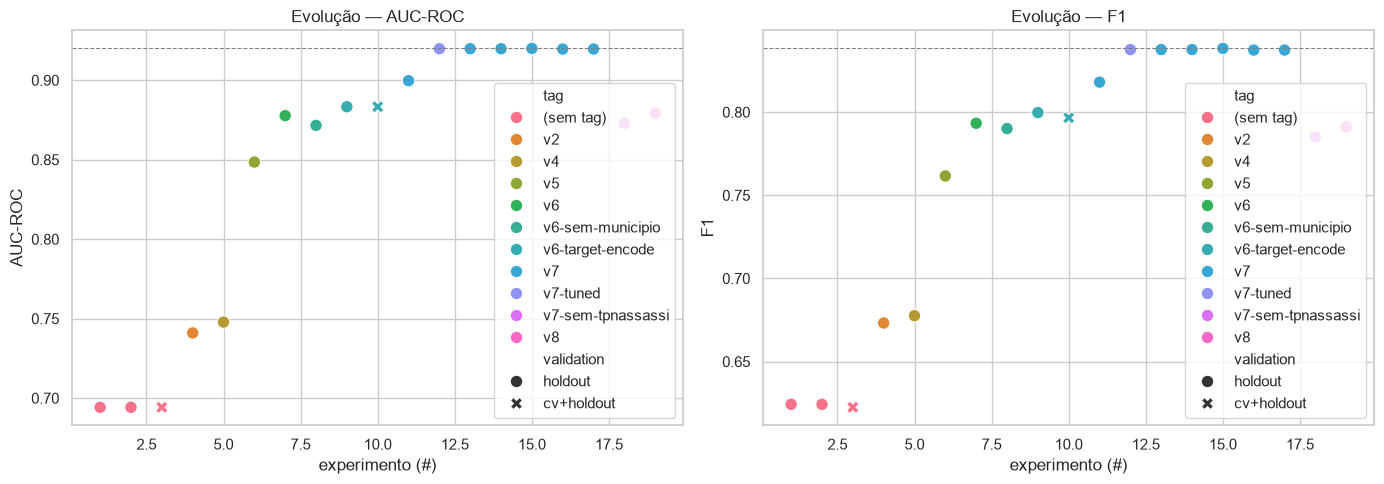

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, col in [
    (axes[0], "roc_auc", "holdout_auc"),
    (axes[1], "f1", "metrics.f1"),
]:
    sns.scatterplot(
        data=exps,
        x="exp_num",
        y=col,
        hue="tag",
        style="validation",
        s=80,
        ax=ax,
        legend="brief",
    )
    ax.set_xlabel("experimento (#)")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(f"Evolução — {METRIC_LABELS[metric]}")
    ax.axhline(exps[col].max(), ls="--", c="gray", lw=0.8, label="máximo")

plt.tight_layout()
plt.show()

## 4 — Marcos metodológicos

Um ponto por etapa relevante da construção do modelo (último run de cada marco).

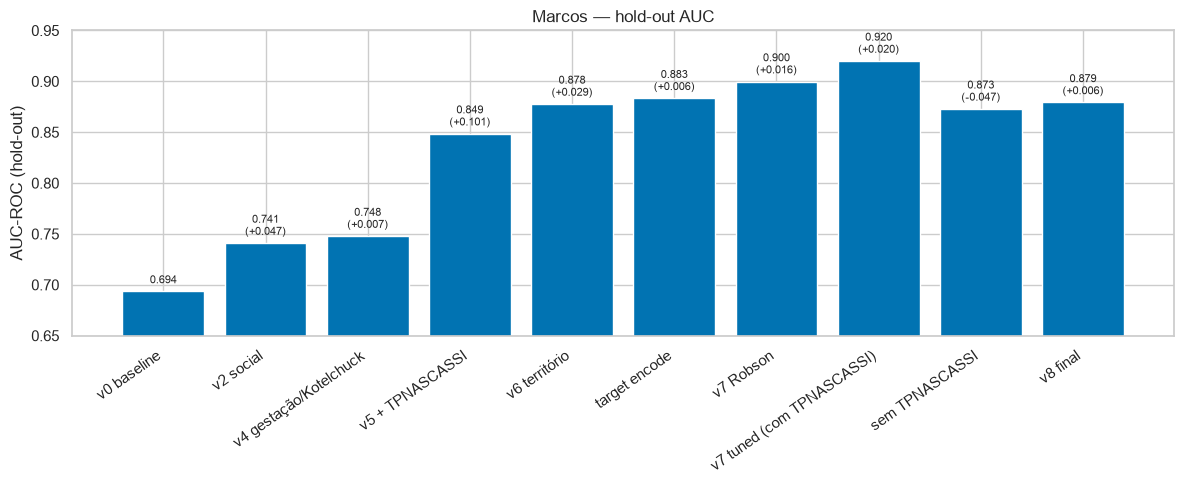

,id,label,holdout_auc,metrics.f1,n_features,delta_auc
0,exp_001,v0 baseline,0.6942,0.6243,421,NaN
3,exp_004,v2 social,0.7410,0.6732,447,0.0468
4,exp_005,v4 gestação/Kotelchuck,0.7478,0.6776,453,0.0068
5,exp_006,v5 + TPNASCASSI,0.8485,0.7616,464,0.1007
6,exp_007,v6 território,0.8777,0.7933,1435,0.0292
8,exp_009,target encode,0.8833,0.7997,53,0.0056
10,exp_011,v7 Robson,0.8997,0.8180,64,0.0164
14,exp_015,v7 tuned (com TPNASCASSI),0.9200,0.8383,54,0.0203
17,exp_018,sem TPNASCASSI,0.8729,0.7851,35,-0.0471
18,exp_019,v8 final,0.8792,0.7911,53,0.0063


In [6]:
MILESTONES = {
    "exp_001": "v0 baseline",
    "exp_004": "v2 social",
    "exp_005": "v4 gestação/Kotelchuck",
    "exp_006": "v5 + TPNASCASSI",
    "exp_007": "v6 território",
    "exp_009": "target encode",
    "exp_011": "v7 Robson",
    "exp_015": "v7 tuned (com TPNASCASSI)",
    "exp_018": "sem TPNASCASSI",
    "exp_019": "v8 final",
}

milestones = (
    exps[exps["id"].isin(MILESTONES)]
    .assign(label=lambda d: d["id"].map(MILESTONES))
    .sort_values("exp_num")
)

milestones["delta_auc"] = milestones["holdout_auc"].diff()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(milestones["label"], milestones["holdout_auc"], color=sns.color_palette()[0])
ax.set_ylabel("AUC-ROC (hold-out)")
ax.set_title("Marcos — hold-out AUC")
ax.set_ylim(0.65, 0.95)
plt.xticks(rotation=35, ha="right")

for bar, auc, delta in zip(bars, milestones["holdout_auc"], milestones["delta_auc"], strict=True):
    label = f"{auc:.3f}"
    if pd.notna(delta):
        label += f"\n({delta:+.3f})"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, label, ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

milestones[["id", "label", "holdout_auc", "metrics.f1", "n_features", "delta_auc"]]

## 5 — Ablation: variável de processo (TPNASCASSI)

Comparando o melhor modelo **com** assistência no parto vs **sem** (determinantes anteparto) e a recuperação parcial no v8.

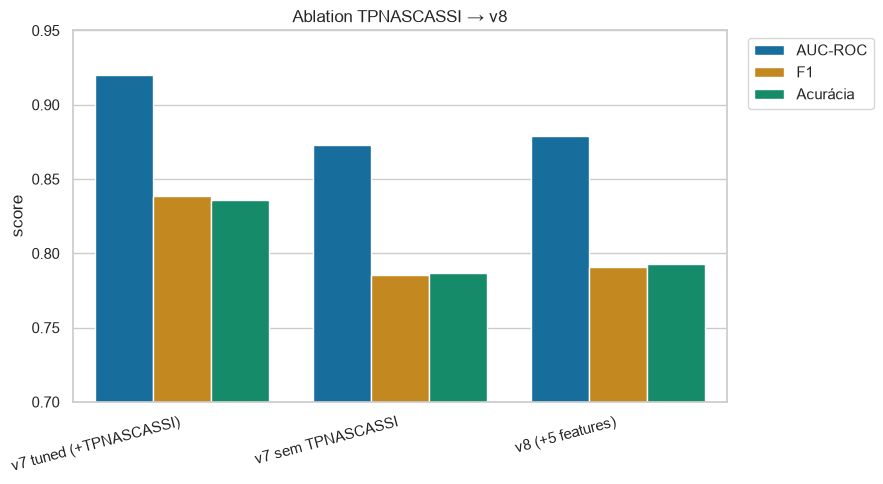

Queda ao remover TPNASCASSI: -0.047 AUC
Recuperação v8 vs sem TPNASCASSI: +0.006 AUC


In [7]:
ablation_ids = ["exp_015", "exp_018", "exp_019"]
ablation = exps[exps["id"].isin(ablation_ids)].assign(
    label=["v7 tuned (+TPNASCASSI)", "v7 sem TPNASCASSI", "v8 (+5 features)"]
)

metrics_long = ablation.melt(
    id_vars=["id", "label"],
    value_vars=["holdout_auc", "metrics.f1", "metrics.accuracy"],
    var_name="metric",
    value_name="value",
).replace(
    {
        "holdout_auc": "AUC-ROC",
        "metrics.f1": "F1",
        "metrics.accuracy": "Acurácia",
    }
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=metrics_long, x="label", y="value", hue="metric", ax=ax)
ax.set_ylim(0.7, 0.95)
ax.set_xlabel("")
ax.set_ylabel("score")
ax.set_title("Ablation TPNASCASSI → v8")
plt.xticks(rotation=15, ha="right")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

drop_auc = ablation.loc[ablation["id"] == "exp_018", "holdout_auc"].iloc[0] - ablation.loc[
    ablation["id"] == "exp_015", "holdout_auc"
].iloc[0]
recover_auc = ablation.loc[ablation["id"] == "exp_019", "holdout_auc"].iloc[0] - ablation.loc[
    ablation["id"] == "exp_018", "holdout_auc"
].iloc[0]
print(f"Queda ao remover TPNASCASSI: {drop_auc:+.3f} AUC")
print(f"Recuperação v8 vs sem TPNASCASSI: {recover_auc:+.3f} AUC")

## 6 — Top-5 importâncias (runs selecionados)

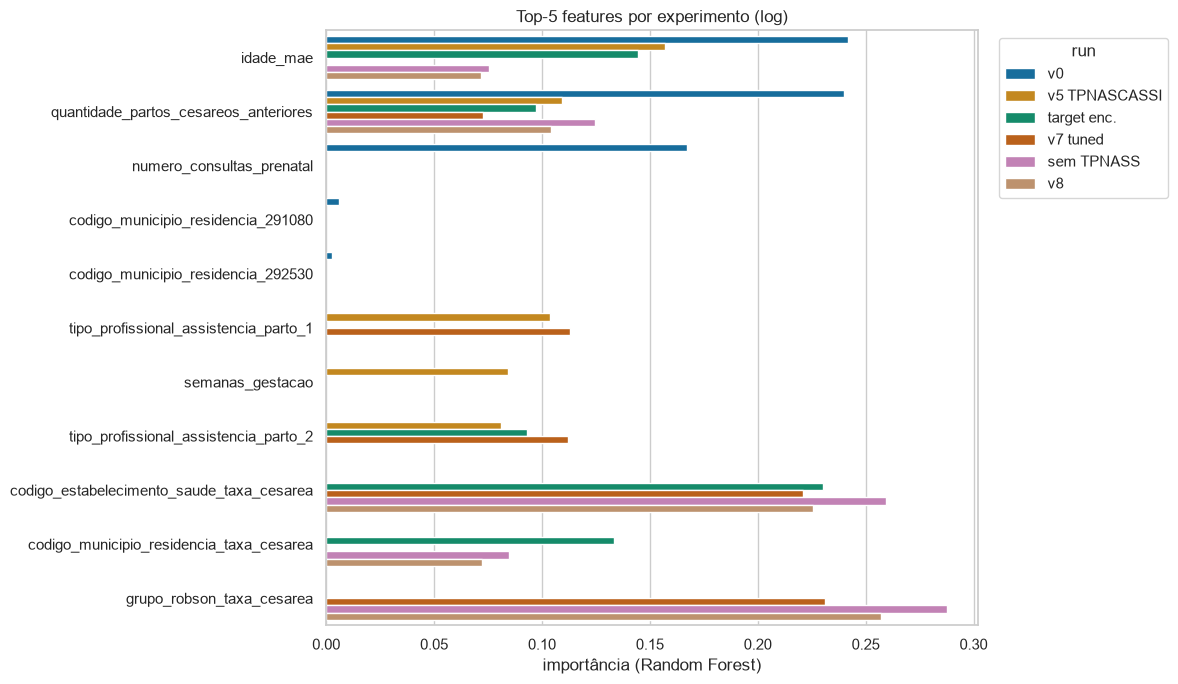

In [8]:
focus_ids = ["exp_001", "exp_006", "exp_009", "exp_015", "exp_018", "exp_019"]
focus = imps[imps["id"].isin(focus_ids)].copy()
focus["label"] = focus["id"].map({k: v for k, v in zip(focus_ids, [
    "v0", "v5 TPNASCASSI", "target enc.", "v7 tuned", "sem TPNASS", "v8",
], strict=True)})

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=focus,
    y="feature",
    x="importance",
    hue="label",
    dodge=True,
    ax=ax,
)
ax.set_xlabel("importância (Random Forest)")
ax.set_ylabel("")
ax.set_title("Top-5 features por experimento (log)")
plt.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7 — CV vs hold-out

Quando `validation=cv+holdout`, a métrica principal no log é a **média CV**; o hold-out fica em `holdout_metrics`.

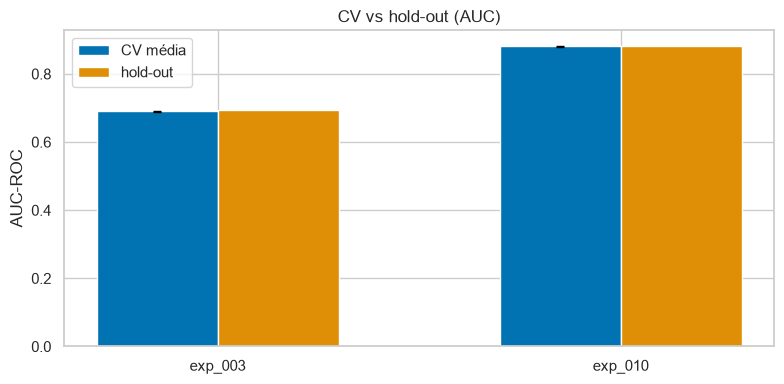

In [9]:
cv_runs = exps[exps["validation"] == "cv+holdout"].copy()

if cv_runs.empty:
    print("Nenhum experimento com CV no log.")
else:
    rows = []
    for _, row in cv_runs.iterrows():
        for metric in ["roc_auc", "f1", "accuracy"]:
            rows.append(
                {
                    "id": row["id"],
                    "tag": row["tag"],
                    "metric": METRIC_LABELS[metric],
                    "cv_mean": row[f"metrics.{metric}"],
                    "cv_std": row.get(f"cv_metrics_std.{metric}"),
                    "holdout": row.get(f"holdout_metrics.{metric}"),
                }
            )
    cv_table = pd.DataFrame(rows)
    cv_table

    fig, ax = plt.subplots(figsize=(8, 4))
    auc_rows = cv_table[cv_table["metric"] == "AUC-ROC"]
    x = np.arange(len(auc_rows))
    ax.bar(x - 0.15, auc_rows["cv_mean"], width=0.3, label="CV média")
    ax.bar(x + 0.15, auc_rows["holdout"], width=0.3, label="hold-out")
    ax.errorbar(x - 0.15, auc_rows["cv_mean"], yerr=auc_rows["cv_std"], fmt="none", c="black", capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(auc_rows["id"])
    ax.set_ylabel("AUC-ROC")
    ax.set_title("CV vs hold-out (AUC)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 8 — Cardinalidade vs desempenho

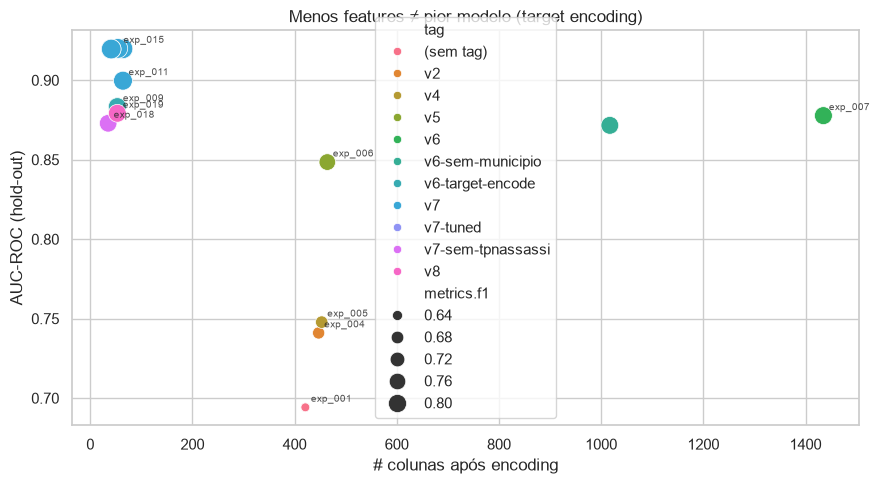

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=exps,
    x="n_features",
    y="holdout_auc",
    hue="tag",
    size="metrics.f1",
    sizes=(40, 200),
    ax=ax,
)
for _, row in milestones.iterrows():
    ax.annotate(
        row["id"],
        (row["n_features"], row["holdout_auc"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=7,
        alpha=0.8,
    )
ax.set_xlabel("# colunas após encoding")
ax.set_ylabel("AUC-ROC (hold-out)")
ax.set_title("Menos features ≠ pior modelo (target encoding)")
plt.tight_layout()
plt.show()

## 9 — Modelo v8: importâncias completas (se `.joblib` existir)

Carrega o artefato salvo em `data/processed/` e plota todas as importâncias — útil além do top-5 do log.

Features brutas (pré-encoding): 18 cols
Colunas pós-encoding: 53
Modelo: /Users/antonielmagalhaes/d/acad/ia-final/ia-iii/data/processed/model_rf_v8.joblib


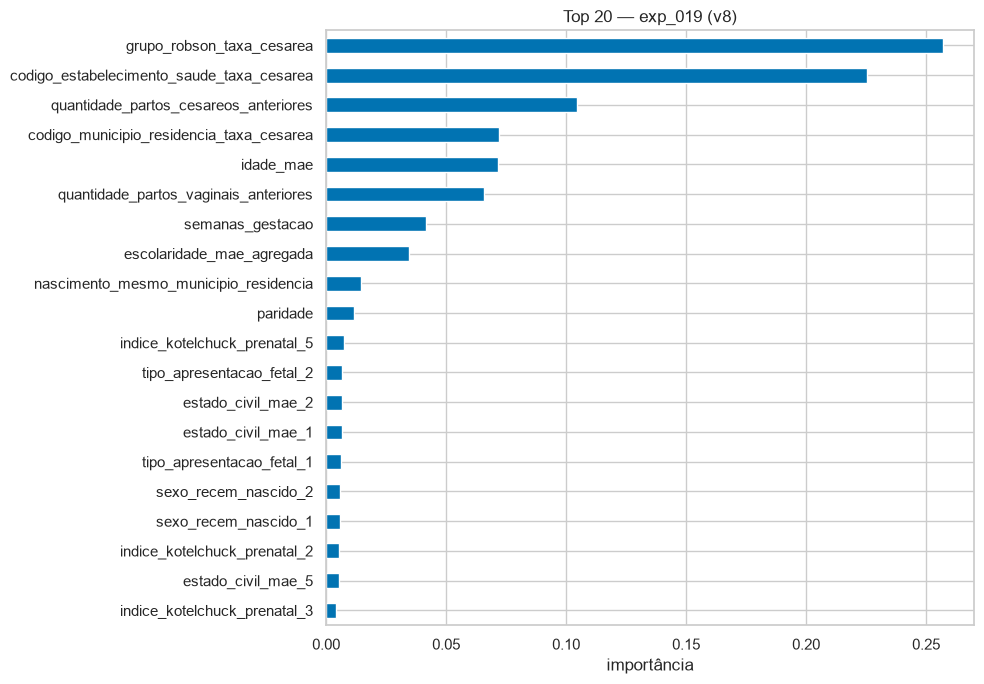

In [11]:
v8 = exps[exps["id"] == "exp_019"].iloc[0]
model_path = ROOT / v8["model_path"]

print("Features brutas (pré-encoding):", len(v8["config.feature_columns"]), "cols")
print("Colunas pós-encoding:", int(v8["n_features"]))
print("Modelo:", model_path)

if not model_path.exists():
    print("\nArtefato não encontrado — rode `uv run ia-iii` na raiz do projeto para gerar.")
else:
    from ml.columns import FEATURES_V8
    from ml.dataset import build_xy, load_features, split_train_test
    from ml.validate import feature_importances

    model = joblib.load(model_path)
    df_raw = load_features(ROOT / v8["config.input_path"])
    train_df, _ = split_train_test(
        df_raw,
        test_size=float(v8["config.test_size"]),
        random_state=int(v8["config.random_state"]),
    )
    x_train, _, _ = build_xy(train_df, FEATURES_V8)
    full_imp = feature_importances(model, list(x_train.columns)).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    full_imp.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette()[0])
    ax.set_xlabel("importância")
    ax.set_title(f"Top 20 — {v8['id']} ({v8['tag']})")
    plt.tight_layout()
    plt.show()

    full_imp.to_frame("importance").head(15)

## 10 — Diff de features entre marcos

O que entrou / saiu entre v7 sem TPNASCASSI e v8.

In [12]:
def feature_set(exp_id: str) -> set[str]:
    cols = exps.loc[exps["id"] == exp_id, "config.feature_columns"].iloc[0]
    return set(cols)


before = feature_set("exp_018")
after = feature_set("exp_019")

added = sorted(after - before)
removed = sorted(before - after)

print("v8 adicionou:", added or "(nada)")
print("v8 removeu:", removed or "(nada)")
print(f"\nContagem: {len(before)} → {len(after)} features brutas")

v8 adicionou: ['estado_civil_mae', 'nascimento_mesmo_municipio_residencia', 'quantidade_partos_vaginais_anteriores', 'raca_cor_recem_nascido', 'sexo_recem_nascido']
v8 removeu: (nada)

Contagem: 13 → 18 features brutas
